# Vantara — 01 EDA

This notebook is an auditable consumer of reusable `src/` logic. It does not own production transformations. All displayed tables and figures are generated by `src.analysis.eda` from governed STEP 02 artifacts.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.analysis.eda import run_step03_analysis  # noqa: E402

summary = run_step03_analysis(ROOT / 'config/config.yaml', project_root=ROOT)
summary

{'step': 'STEP 03',
 'schema_version': 'vantara-churn-features-v1',
 'selected_feature_count': 47,
 'excluded_feature_count': 5,
 'selected_features': ['frequency_orders',
  'avg_order_value',
  'avg_basket_units',
  'avg_distinct_products_per_order',
  'recency_days',
  'customer_tenure_days',
  'unique_product_count',
  'net_spend',
  'mean_interpurchase_gap_days',
  'variance_interpurchase_gap_days',
  'purchase_frequency_trend',
  'seasonal_purchase_concentration',
  'return_rate',
  'markdown_affinity_proxy',
  'mean_product_popularity',
  'median_product_popularity',
  'max_product_popularity',
  'rare_product_share',
  'category_affinity_01',
  'category_affinity_02',
  'category_affinity_03',
  'category_affinity_04',
  'category_affinity_05',
  'category_affinity_06',
  'category_affinity_07',
  'category_affinity_08',
  'category_affinity_09',
  'category_affinity_10',
  'category_affinity_11',
  'category_affinity_12',
  'category_affinity_13',
  'category_affinity_14',
  'c

## Spend, frequency, and recency

,feature,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
0,recency_days,4952,217.359162,174.158153,0.872917,1.901444,16.988819,59.060243,179.513542,331.308507,485.026736,639.920590,648.084028
1,frequency_orders,4952,5.974152,11.499587,1.000000,1.000000,1.000000,1.000000,3.000000,6.000000,13.000000,43.000000,284.000000
2,gross_spend,4952,2733.784917,12448.655480,1.550000,42.112200,162.073000,331.215000,832.600000,2163.400000,5236.683000,27225.932600,456780.490000
3,net_spend,4952,2642.615406,12147.678750,0.000000,35.919300,157.710000,323.287500,817.090000,2106.355000,5007.242000,25952.561200,454202.090000
4,avg_order_value,4952,370.798466,650.227628,1.550000,36.225500,118.833000,174.987500,276.204167,406.700873,630.193100,1918.071912,25784.320000


,churn,recency_days_median,recency_days_mean,frequency_orders_median,frequency_orders_mean,gross_spend_median,gross_spend_mean,net_spend_median,net_spend_mean,avg_order_value_median,avg_order_value_mean
0,0,78.871528,127.635240,6,9.766730,1785.065,4849.925528,1739.505,4727.600745,306.689286,398.839760
1,1,291.854167,284.636251,2,3.130389,499.750,1147.053336,491.205,1079.244774,247.240000,349.772449


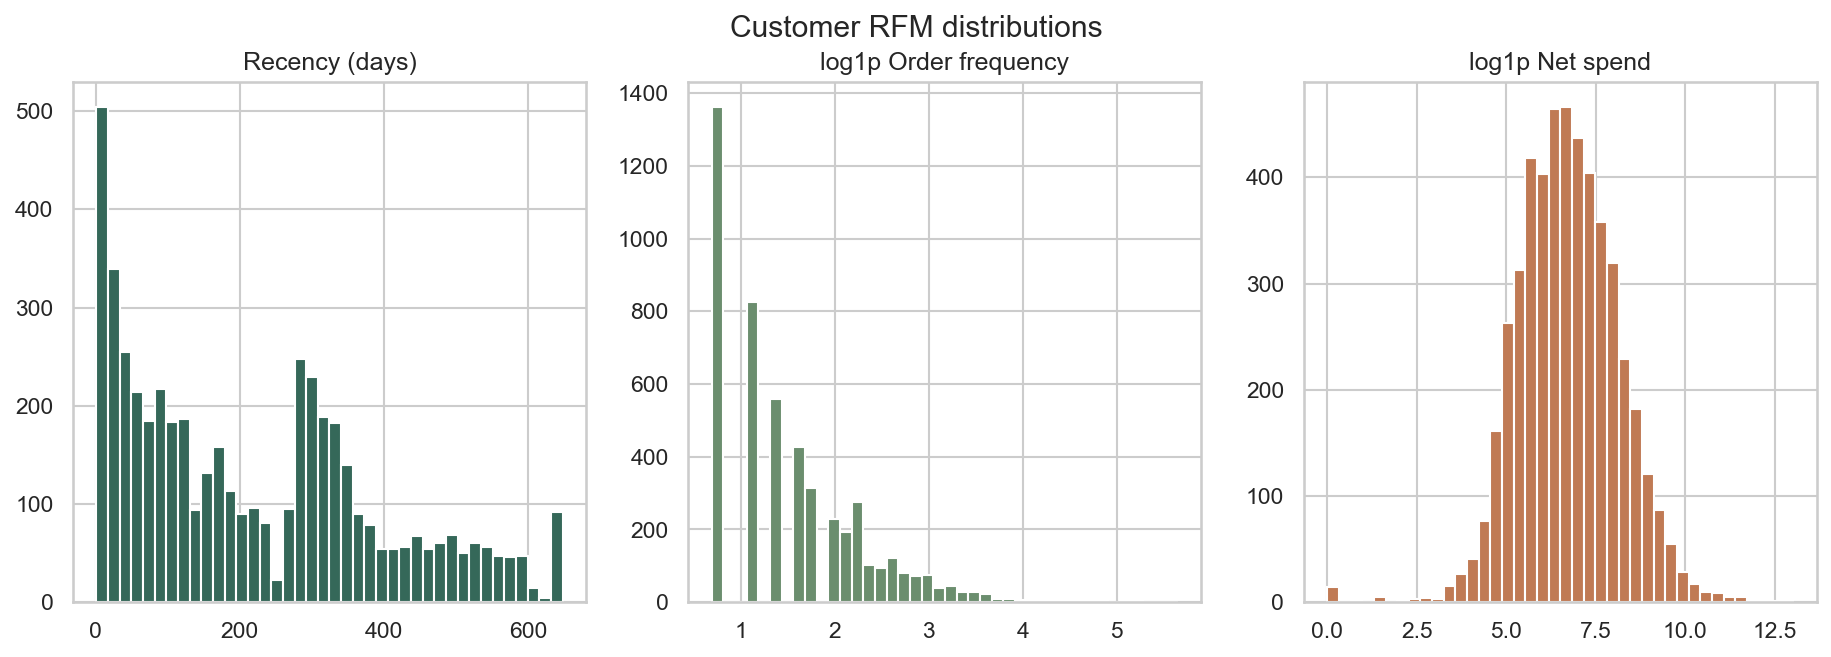

In [2]:
eda_dir = ROOT / 'reports/eda'
rfm = pd.read_csv(eda_dir / 'rfm_summary.csv')
comparison = pd.read_csv(eda_dir / 'churn_rfm_comparison.csv')
display(rfm)
display(comparison)
display(Image(filename=str(eda_dir / 'rfm_distributions.png')))

## Churn target balance

,churn,customers,proportion
0,0,2122,0.428514
1,1,2830,0.571486


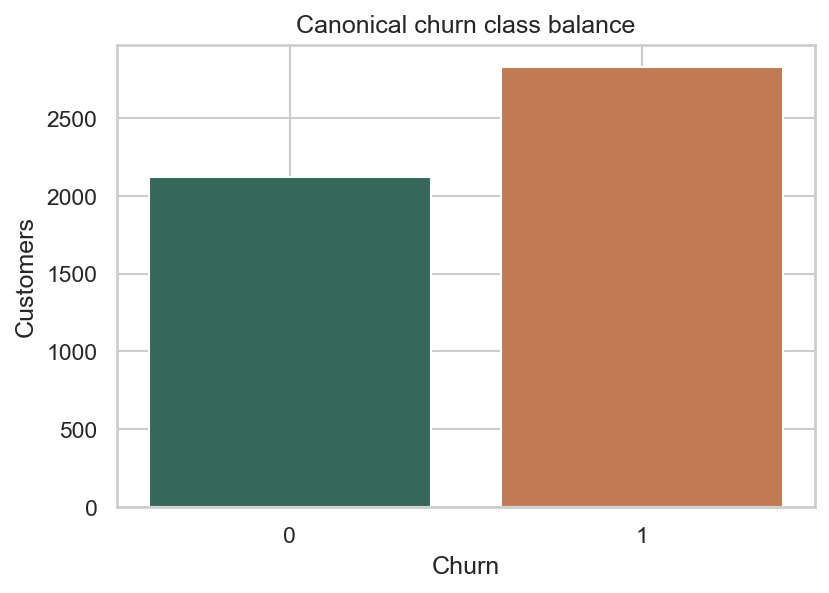

In [3]:
display(pd.read_csv(eda_dir / 'class_balance.csv'))
display(Image(filename=str(eda_dir / 'churn_class_balance.png')))

## Country analysis

,country,orders,identified_customers,gross_revenue,units
0,United Kingdom,36184,5334,16801004.62,9176169
1,EIRE,581,3,623414.16,336088
2,Netherlands,216,22,549773.41,383625
3,Germany,753,107,383289.00,223088
4,France,598,93,311090.29,270582
5,Australia,89,15,167800.01,103753
6,Spain,144,38,97766.75,49996
7,Switzerland,85,22,94024.59,52612
8,Sweden,99,19,86319.14,88537
9,Denmark,42,12,67422.69,237406


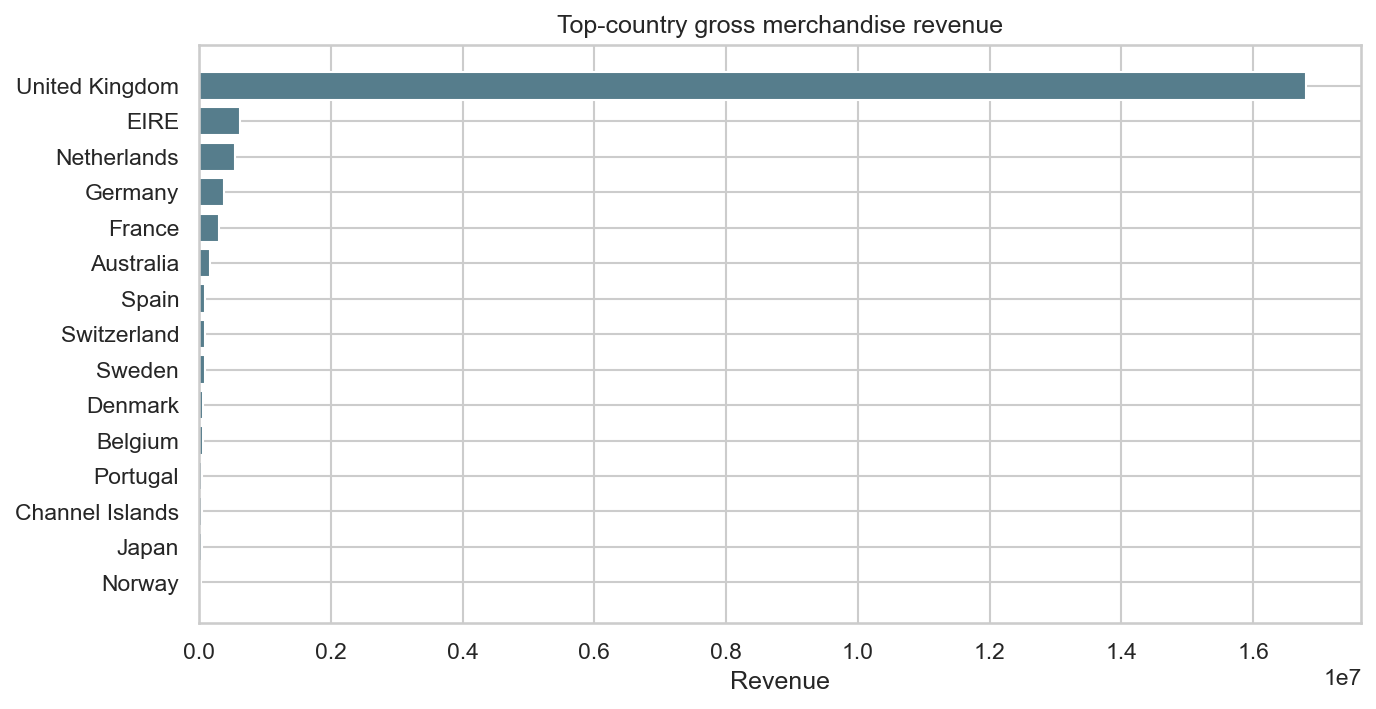

In [4]:
display(pd.read_csv(eda_dir / 'country_summary.csv'))
display(Image(filename=str(eda_dir / 'country_revenue.png')))

## Seasonality

,year_month,quarter,orders,gross_revenue,units
0,2009-12,4,1666,797901.16,425218
1,2010-01,1,1049,612297.42,390412
2,2010-02,1,1189,537909.67,381620
3,2010-03,1,1647,761705.98,525042
4,2010-04,2,1435,646340.93,366065
5,2010-05,2,1484,643492.03,395438
6,2010-06,2,1612,696583.19,406238
7,2010-07,3,1507,632994.32,337556
8,2010-08,3,1402,674037.72,471931
9,2010-09,3,1789,869243.12,583366


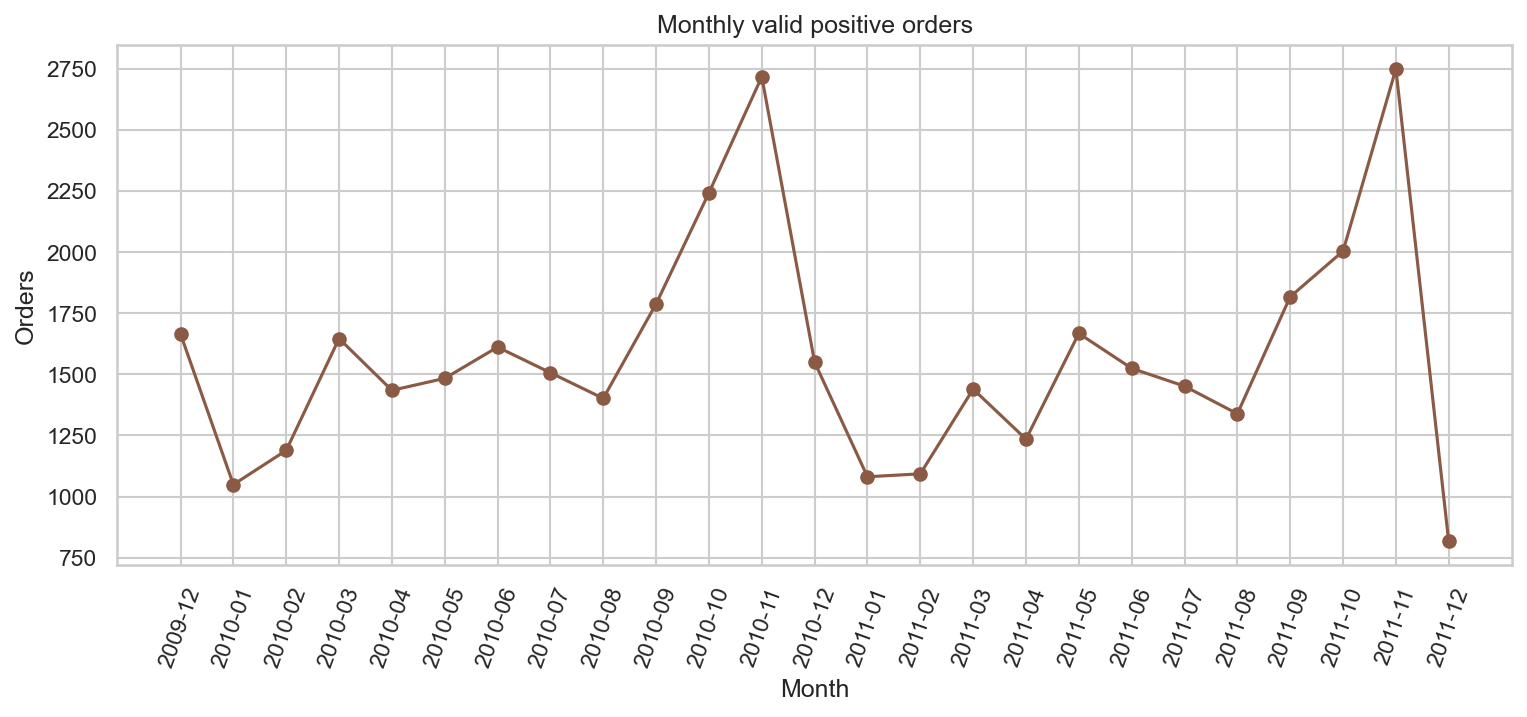

In [5]:
display(pd.read_csv(eda_dir / 'seasonality_summary.csv'))
display(Image(filename=str(eda_dir / 'monthly_orders.png')))

## Outlier and data-quality review

In [6]:
display(pd.read_csv(eda_dir / 'outlier_summary.csv'))

,quality_flag,rows,proportion
0,is_missing_customer_id,235151,0.227631
1,is_return,22496,0.021777
2,is_cancelled_invoice,19104,0.018493
3,is_non_positive_price,6019,0.005827
4,is_administrative_line,5821,0.005635
5,is_statistical_outlier,81830,0.079213
6,is_likely_data_error,0,0.000000


## Written modeling hypotheses

In [7]:
display(Markdown((eda_dir / 'hypotheses.md').read_text(encoding='utf-8')))

# STEP 03 Modeling Hypotheses

- H1: Higher recency should increase churn risk; training evidence shows median recency 291.9 days for churned versus 78.9 for active customers.

- H2: Higher order frequency should reduce churn risk; medians are 2.0 versus 6.0 orders.

- H3: Net spend and basket behavior should add value beyond frequency, while correlation/VIF evidence must prevent redundant monetary inputs.

- H4: Return rate and markdown affinity may identify behaviorally distinct risk groups and should be tested as interactions rather than causal effects.

- H5: Seasonality should affect purchase timing; observed gross revenue peaks in 2011-11 and must be interpreted using pre-cutoff features only.

- H6: Country mix may affect behavior; United Kingdom contributes 86.6% of revenue among the displayed top countries, so country results require scale-aware interpretation.

- H7: Frozen category affinities and training-only product popularity should improve behavioral separation without target leakage.
